# Proyecto: Clasificador Multi-Clase
### Hugo Rigoberto Orozco Urlá - 26006717

## 1. Contexto

**Dataset seleccionado:** `Palmer Penguins`

**Tipo de problema:** Clasificación Multi-Clase

**Justificación:** El dataset posee una cantidad pequeña pero adecuada de datos para poder entrenar un modelo de clasificación. Debido a su dificultad, el dataset permite realizar análisis de forma clara para demostrar las diferencias entre distintos modelos de machine learning.

**Variable objetivo:** `Species`.

**Modelos evaluados:** Random Forest, XGBoost, Red Neuronal.

## 2. Preparación de datos

In [1]:

%pip install -q jinja2 palmerpenguins numpy pandas matplotlib seaborn scikit-learn xgboost tensorflow
from palmerpenguins import load_penguins
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from scipy import stats
from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
TEST_SIZE = 0.20

np.set_printoptions(precision=2)

# Silenciar logs ruidosos de TensorFlow
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

# Estilo de gráficas (fondo blanco, legible)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.grid':False,'font.size':11})

Note: you may need to restart the kernel to use updated packages.


### Carga de Datos

In [2]:
dataset_raw = load_penguins()
dataset_raw.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
dataset_raw.shape

(344, 8)

In [4]:
summary_raw = pd.DataFrame({
    'dtype': dataset_raw.dtypes.astype(str),
    'nulos': dataset_raw.isna().sum(),
    'unicos': dataset_raw.nunique(),
})
summary_raw

,dtype,nulos,unicos
species,str,0,3
island,str,0,3
bill_length_mm,float64,2,164
bill_depth_mm,float64,2,80
flipper_length_mm,float64,2,55
body_mass_g,float64,2,94
sex,str,11,2
year,int64,0,3


### Exploración de Datos

In [5]:
numerical_columns = dataset_raw.select_dtypes(include=['number', 'float64']).columns
numerical_columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year'], dtype='str')

Skewness of numerical columns:
  bill_length_mm: 0.0531


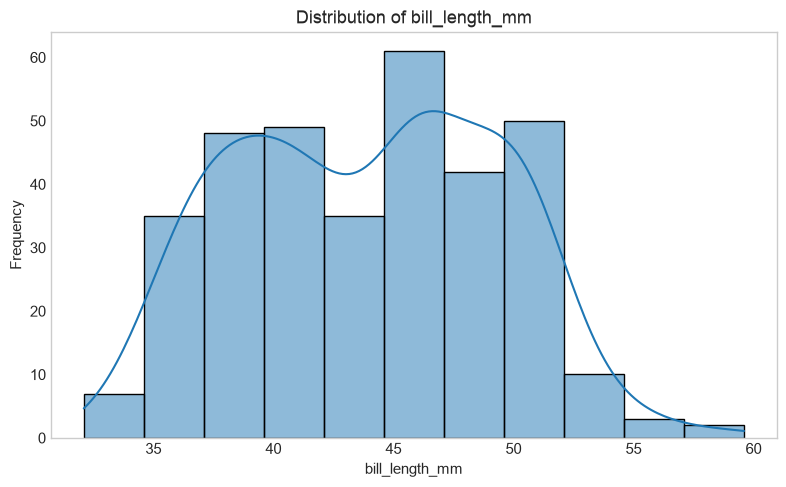

  bill_depth_mm: -0.1435


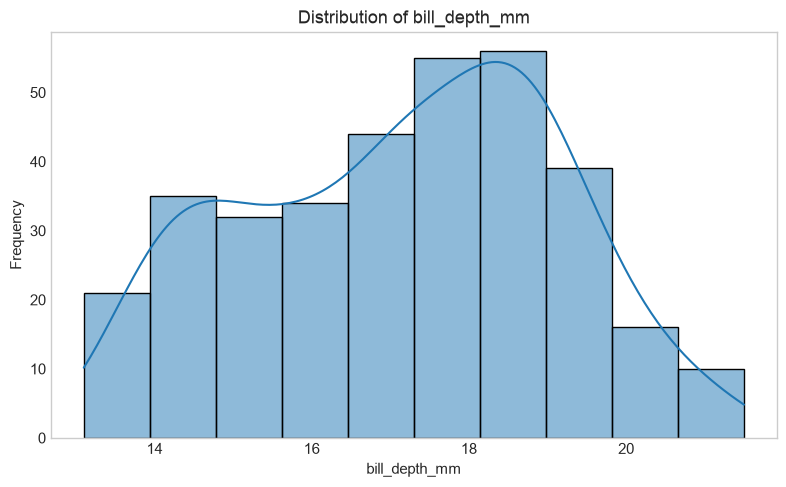

  flipper_length_mm: 0.3457


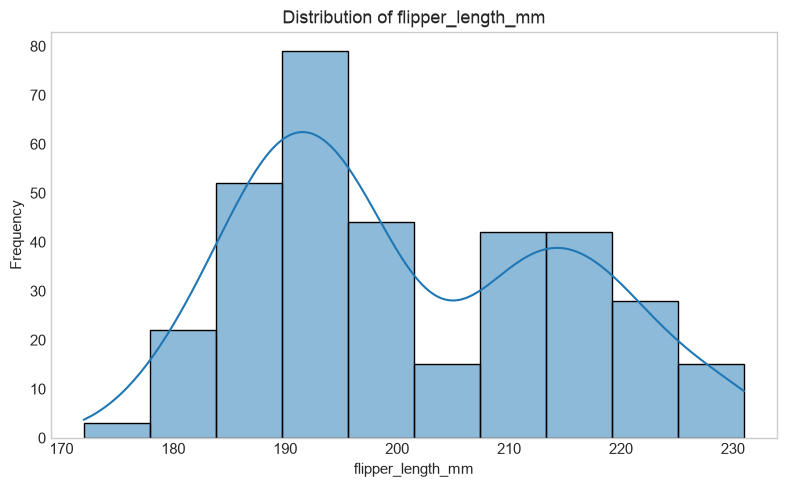

  body_mass_g: 0.4703


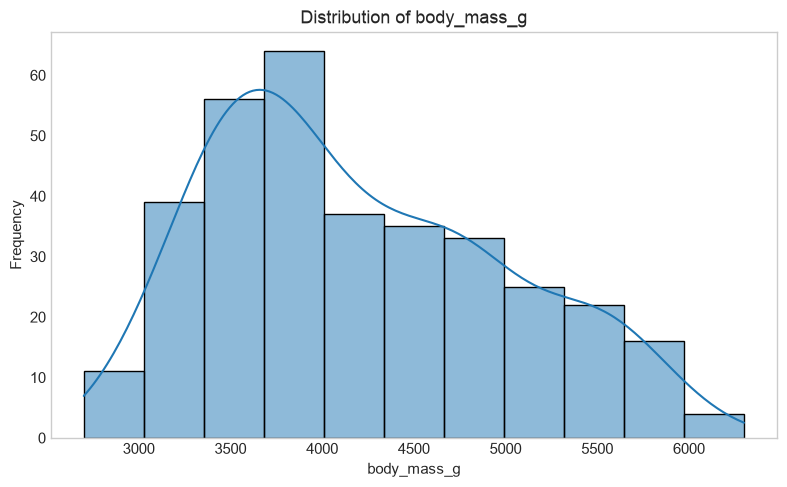

  year: -0.0537


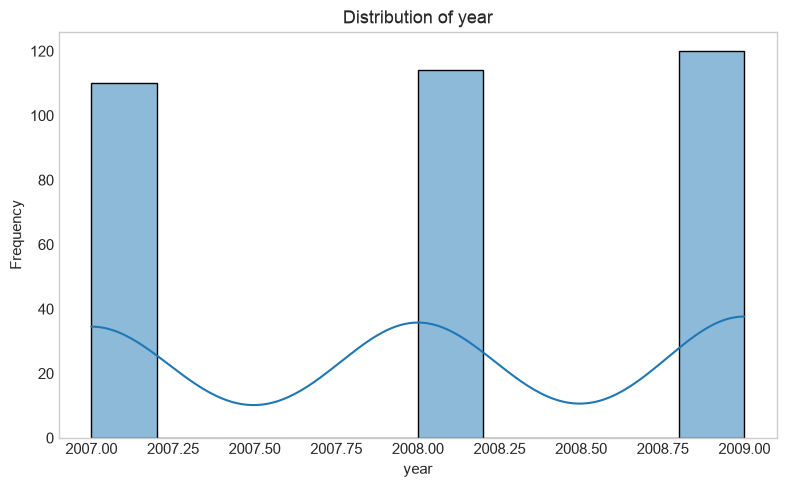

In [6]:
num_cols = numerical_columns.tolist()

print("Skewness of numerical columns:")
for col in num_cols:
    skew_val = dataset_raw[col].skew()
    print(f"  {col}: {skew_val:.4f}")

    plt.figure(figsize=(8, 5))
    sns.histplot(dataset_raw[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

Los datos de las columnas numéricas tienen distribuciones en rangos simétricos, no se observan distribuciones con simetría fuera de rango [-0.5, 0.5] que requieran realizar algún tipo de transformación de distribución.

In [7]:
categorical_columns = dataset_raw.select_dtypes(include=['str']).columns
categorical_columns

Index(['species', 'island', 'sex'], dtype='str')

In [8]:
for column in categorical_columns:
    unique_values = dataset_raw[column].unique()
    print(f"\nColumn: '{column}'")
    print(f"Unique Values: {len(unique_values)}")
    print(unique_values)


Column: 'species'
Unique Values: 3
<StringArray>
['Adelie', 'Gentoo', 'Chinstrap']
Length: 3, dtype: str

Column: 'island'
Unique Values: 3
<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

Column: 'sex'
Unique Values: 3
<StringArray>
['male', 'female', nan]
Length: 3, dtype: str


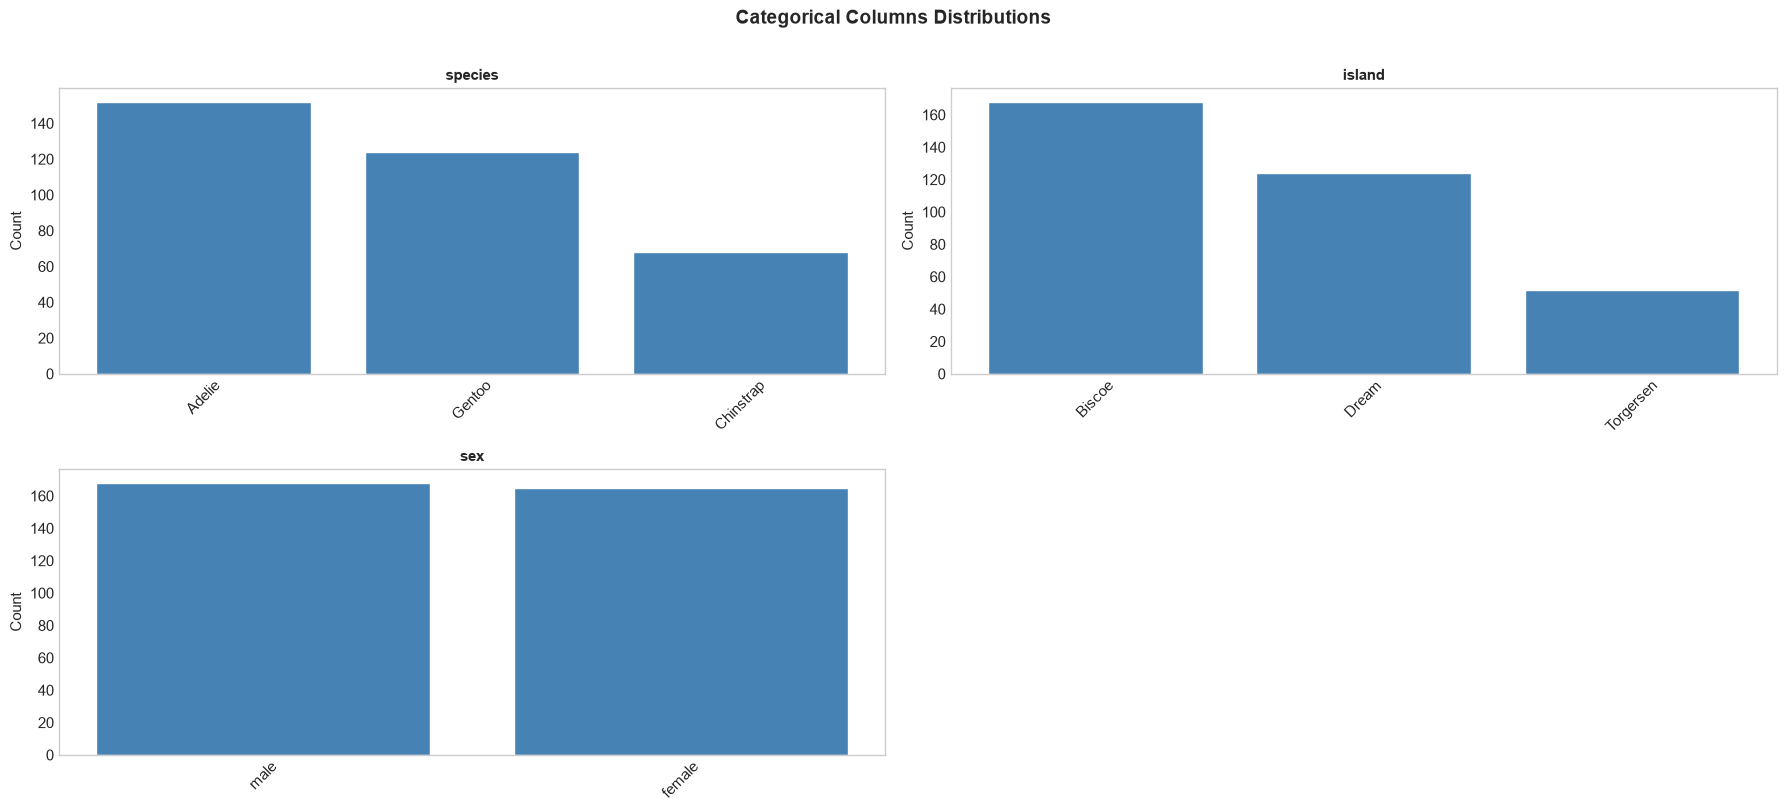

In [9]:
n_cols = 2
n_rows = -(-len(categorical_columns) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    value_counts = dataset_raw[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Categorical Columns Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Se observa cierto sesgo en las variables categóricas "Species" y "Island", puede que este sesgo lleve a algún modelo a predecir correctamente las clases de mayor incidencia y predecir incorrectamente las demás clases, de ser así debemos de realizar algún trabajo de oversampling o undersampling para ajustar las distribuciones.

### Limpieza de Datos

#### Datos Nulos
Debido a que la cantidad de datos nulos no es significativa para el total de datos del dataset, y no sabemos el motivo por el cuál son nulos, se decide eliminar los registros con valores nulos.

In [10]:
print(f'Filas antes de eliminar nulos: {dataset_raw.shape[0]}')
print(f'Valores nulos por columna:\n{dataset_raw.isna().sum()[dataset_raw.isna().sum() > 0]}')

df_clean = dataset_raw.dropna().reset_index(drop=True)

print(f'\nFilas después de eliminar nulos: {df_clean.shape[0]}')
print(f'Filas eliminadas: {dataset_raw.shape[0] - df_clean.shape[0]}')
print(f'Forma final del dataset: {df_clean.shape}')

Filas antes de eliminar nulos: 344
Valores nulos por columna:
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Filas después de eliminar nulos: 333
Filas eliminadas: 11
Forma final del dataset: (333, 8)


#### Filtro de Anomalías
Se Utiliza el Algoritmo de Isolation Forest para poder filtrar las anomalías encontradas en el dataset, se establece un parámetro de "contamination"=0.03 para encontrar una cantidad adecuada de anomalías sin ser muy agresivos y filtrar de forma excesiva.

Procesando columna: bill_length_mm


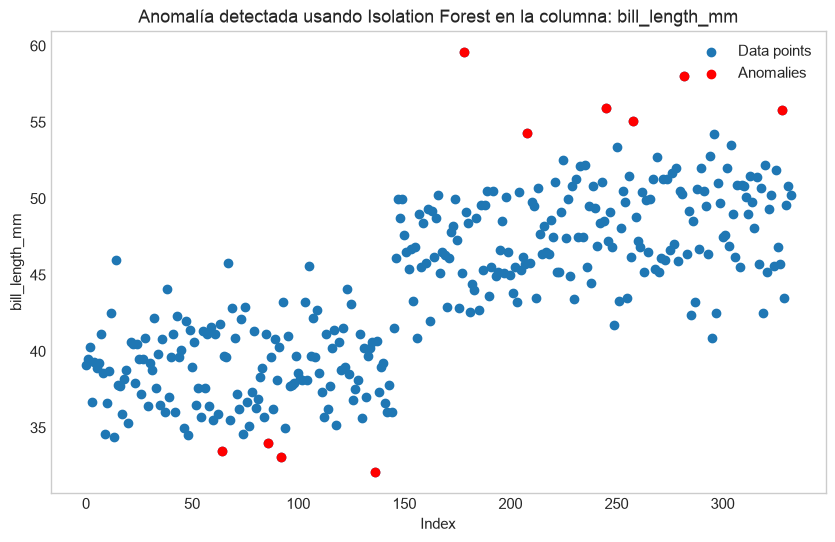

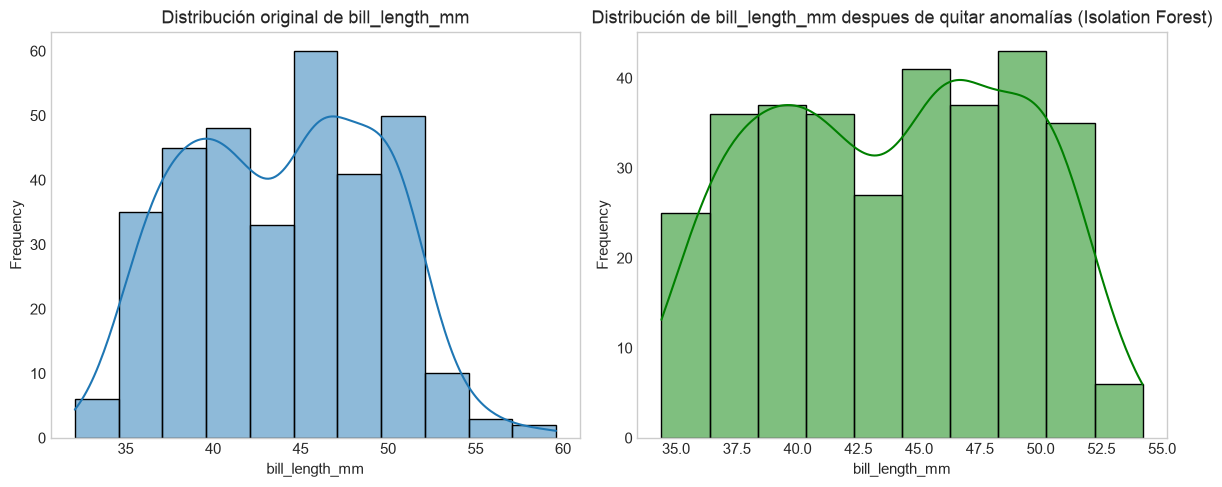


Procesando columna: bill_depth_mm


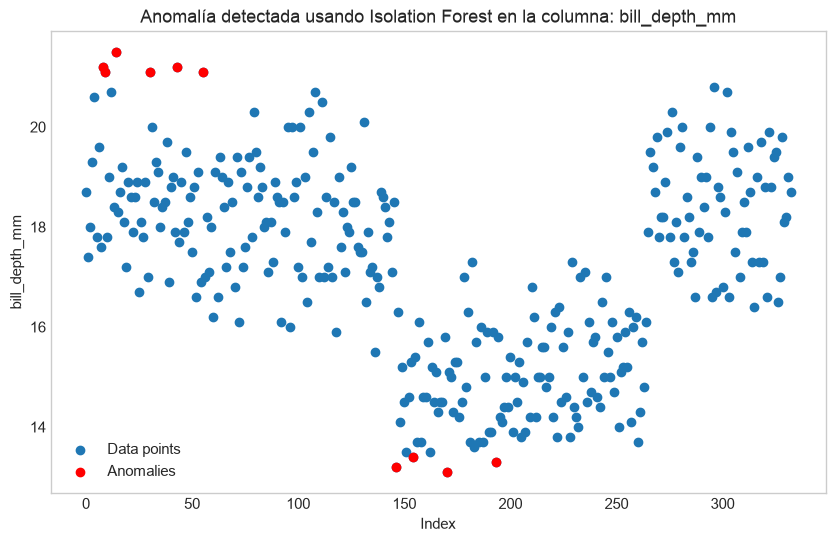

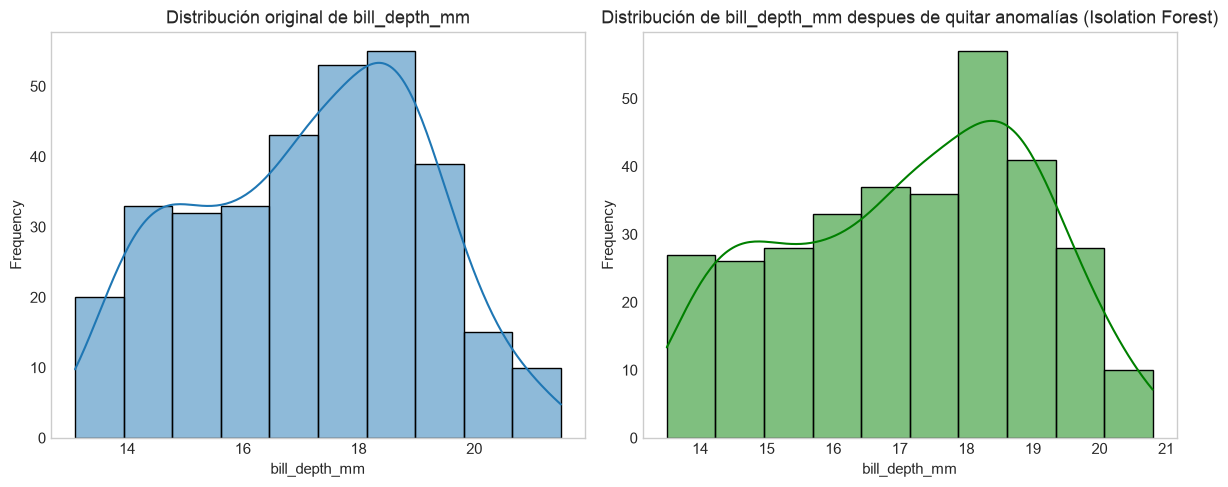


Procesando columna: flipper_length_mm


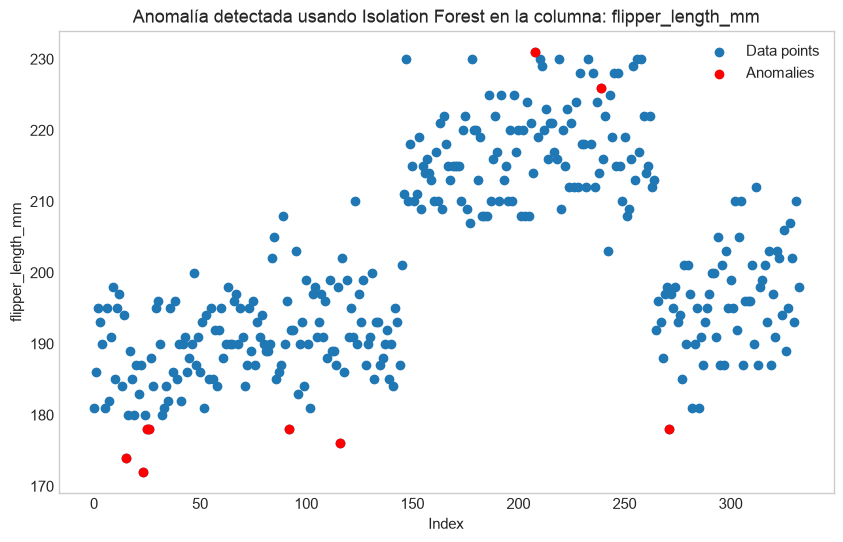

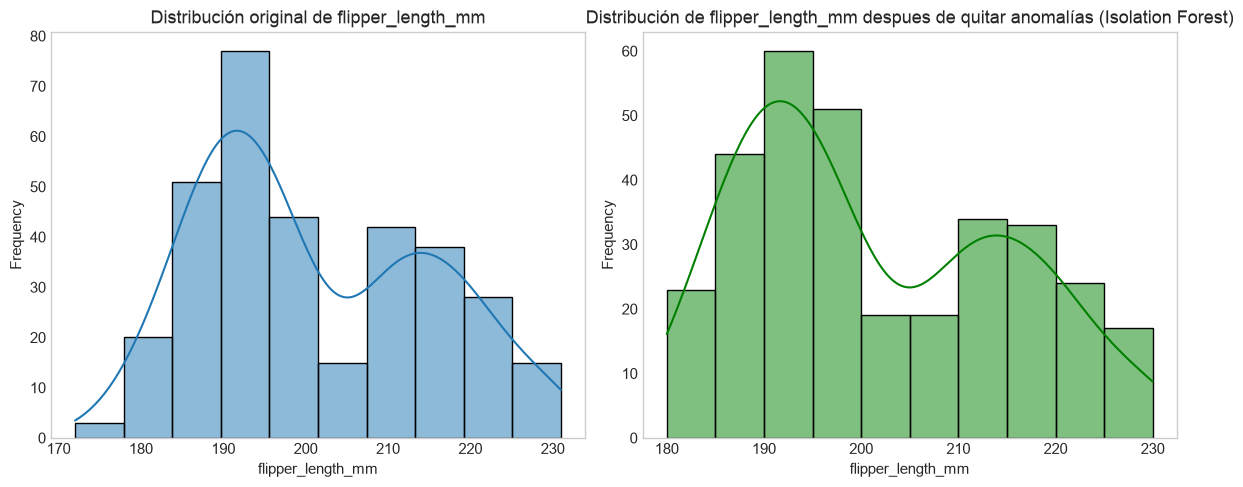


Procesando columna: body_mass_g


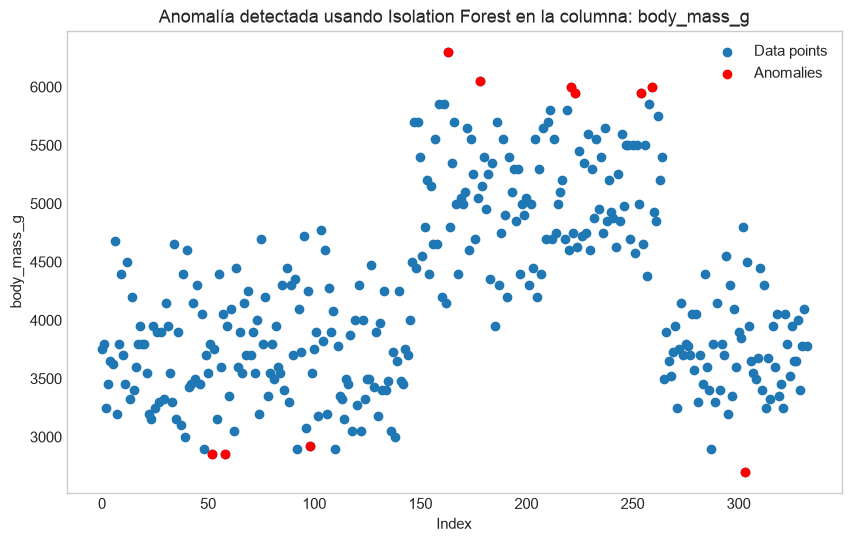

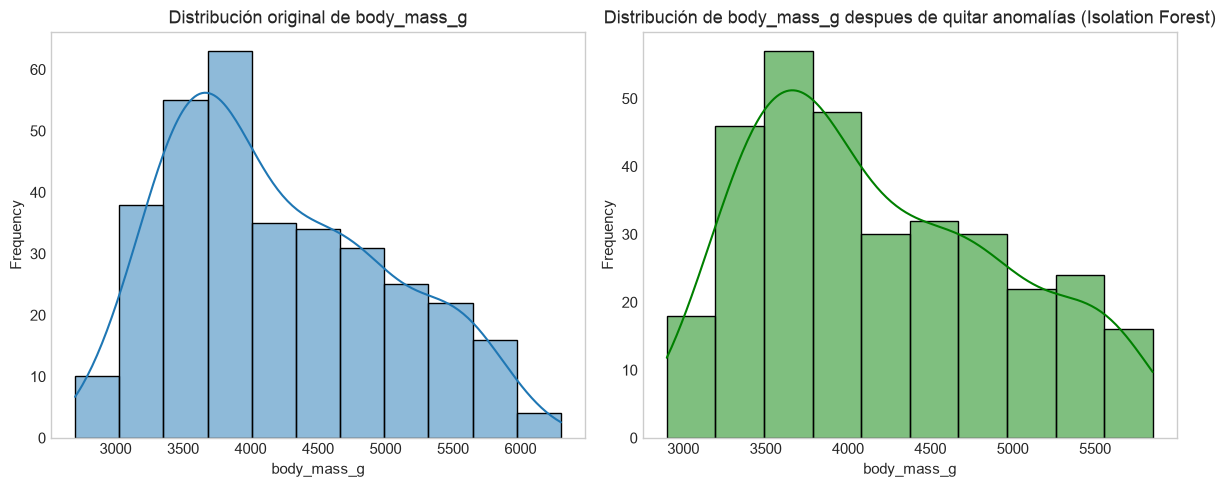


Procesando columna: year


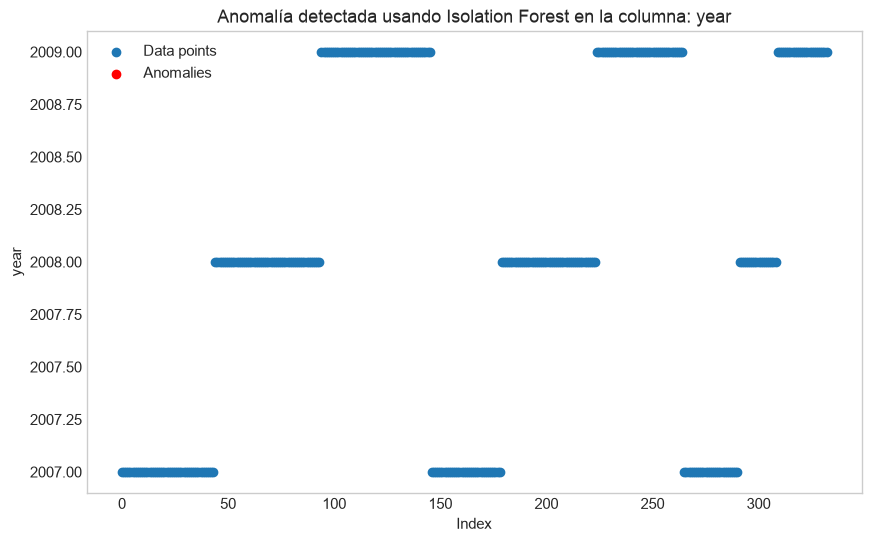

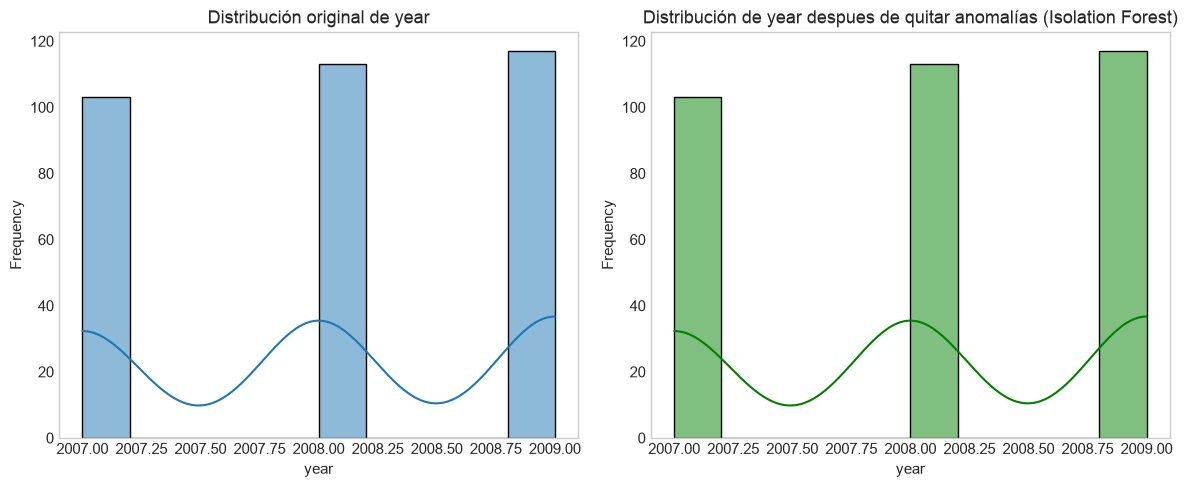

In [11]:
dataset_isolated_forest = df_clean.copy()

for col in numerical_columns:
    if col in dataset_isolated_forest.columns:
        print(f"Procesando columna: {col}")

        data = dataset_isolated_forest[[col]].values

        model = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
        model.fit(data)

        dataset_isolated_forest[f'{col}_anomaly_IF'] = model.predict(data)
        dataset_cleaned = dataset_isolated_forest[dataset_isolated_forest[f'{col}_anomaly_IF'] == 1].copy()

        plt.figure(figsize=(10, 6))
        plt.scatter(dataset_isolated_forest.index, dataset_isolated_forest[col], label='Data points')
        plt.scatter(
            dataset_isolated_forest.index[dataset_isolated_forest[f'{col}_anomaly_IF'] == -1],
            dataset_isolated_forest[col][dataset_isolated_forest[f'{col}_anomaly_IF'] == -1],
            color='red',
            label='Anomalies',
        )
        plt.title(f'Anomalía detectada usando Isolation Forest en la columna: {col}')
        plt.xlabel('Index')
        plt.ylabel(col)
        plt.legend()
        plt.show()

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(dataset_isolated_forest[col], kde=True)
        plt.title(f'Distribución original de {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.subplot(1, 2, 2)
        sns.histplot(dataset_cleaned[col], kde=True, color='green')
        plt.title(f'Distribución de {col} despues de quitar anomalías (Isolation Forest)')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

        print()
    else:
        print(f"Columna '{col}' no encontrada dataset.")


In [12]:

columns_to_filter_if = numerical_columns.copy()
dataset_if_filtered = df_clean.copy()
anomaly_indices_if = set()

for col in columns_to_filter_if:
    if col in dataset_if_filtered.columns:
        data = dataset_if_filtered[[col]].values
        model_if = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
        preds = model_if.fit_predict(data)

        col_anomaly_indices = dataset_if_filtered.index[preds == -1].tolist()
        anomaly_indices_if.update(col_anomaly_indices)

        print(f"Anomalía identificada {len(col_anomaly_indices)} en la columna '{col}' usando Isolation Forest.")
    else:
        print(f"Columna '{col}' no encontrada en el dataset.")

anomaly_indices_if_list = sorted(anomaly_indices_if)
df_raw_filtered = dataset_if_filtered.drop(index=anomaly_indices_if_list).reset_index(drop=True)

print(f"\nForma original del dataset: {df_clean.shape}")
print(f"Forma del dataset ya filtrado {len(anomaly_indices_if)} filas anómalas: {df_raw_filtered.shape}")


print("Dataset después de eliminar anomalías usando Isolation Forest:")
print(df_raw_filtered.shape)

Anomalía identificada 10 en la columna 'bill_length_mm' usando Isolation Forest.
Anomalía identificada 10 en la columna 'bill_depth_mm' usando Isolation Forest.
Anomalía identificada 9 en la columna 'flipper_length_mm' usando Isolation Forest.
Anomalía identificada 10 en la columna 'body_mass_g' usando Isolation Forest.
Anomalía identificada 0 en la columna 'year' usando Isolation Forest.

Forma original del dataset: (333, 8)
Forma del dataset ya filtrado 36 filas anómalas: (297, 8)
Dataset después de eliminar anomalías usando Isolation Forest:
(297, 8)


#### Value Mapping

In [13]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for target variable
le = LabelEncoder()
df_raw_filtered['species'] = le.fit_transform(df_raw_filtered['species'])
print(f"Species classes: {le.classes_}  →  {list(range(len(le.classes_)))}")

# One-hot encoding for remaining categorical columns (excluding species)
categorical_cols = df_raw_filtered.select_dtypes(include=['object', 'string']).columns.tolist()
df_transformed = pd.get_dummies(df_raw_filtered, columns=categorical_cols, drop_first=False, dtype=int)
df_transformed.head()


Species classes: ['Adelie' 'Chinstrap' 'Gentoo']  →  [0, 1, 2]


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,0,39.1,18.7,181.0,3750.0,2007,0,0,1,0,1
1,0,39.5,17.4,186.0,3800.0,2007,0,0,1,1,0
2,0,40.3,18.0,195.0,3250.0,2007,0,0,1,1,0
3,0,36.7,19.3,193.0,3450.0,2007,0,0,1,1,0
4,0,39.3,20.6,190.0,3650.0,2007,0,0,1,0,1


#### Scaling


Skewness of distributions after Z-score normalization:
  bill_length_mm: -0.0740


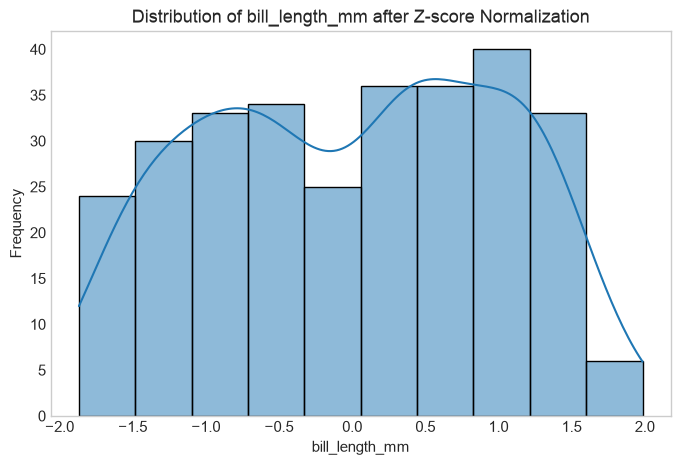

  bill_depth_mm: -0.2343


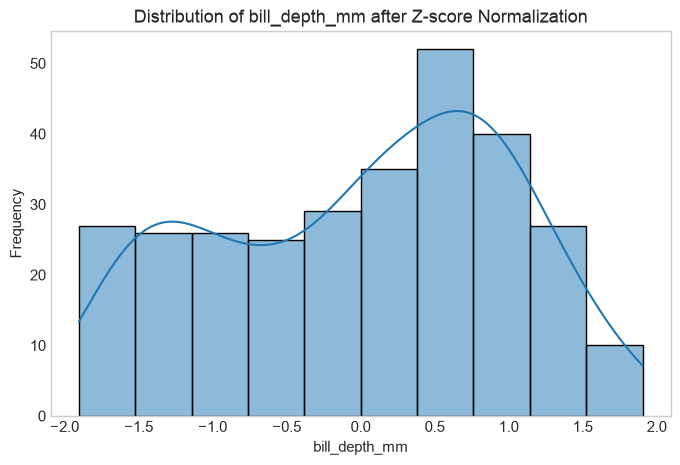

  flipper_length_mm: 0.4087


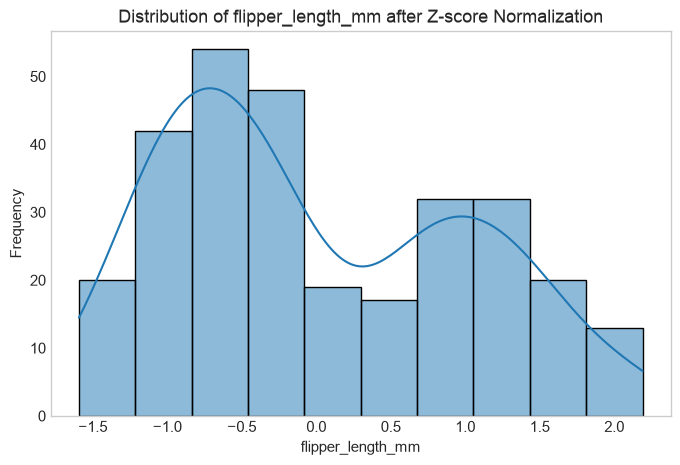

  body_mass_g: 0.4465


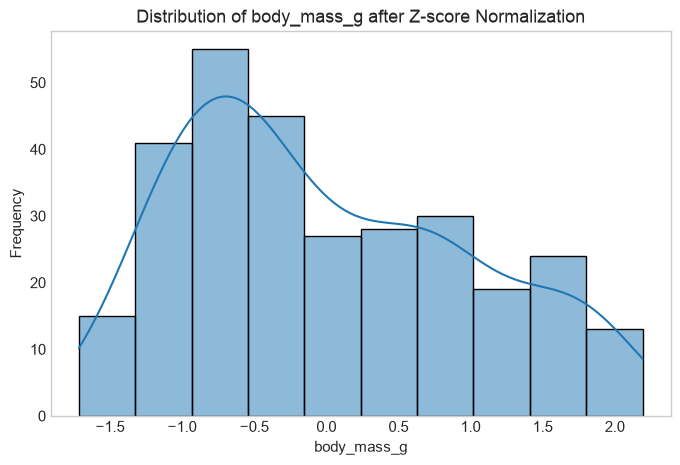

In [14]:
df_clean_scaled = df_transformed.copy()

columns_to_normalize = [
    'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'
]

for col in columns_to_normalize:
    if col in df_clean_scaled.columns:
        df_clean_scaled[col] = stats.zscore(df_clean_scaled[col])
    else:
        print(f"Column '{col}' not found in the dataset for normalization.")

print("\nSkewness of distributions after Z-score normalization:")
for col in columns_to_normalize:
    if col in df_clean_scaled.columns:
        skewness = df_clean_scaled[col].skew()
        print(f"  {col}: {skewness:.4f}")
        # Visualize the distribution after normalization
        plt.figure(figsize=(8, 5))
        sns.histplot(df_clean_scaled[col], kde=True)
        plt.title(f'Distribution of {col} after Z-score Normalization')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

### Data Para Entrenamiento

In [15]:
from sklearn.model_selection import train_test_split

# Separate features and target
x = df_clean_scaled.drop(columns=['species'])
y = df_clean_scaled['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Clases: {le.classes_}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")


Clases: ['Adelie' 'Chinstrap' 'Gentoo']
X_train: (237, 10)  |  X_test: (60, 10)
y_train: (237,)  |  y_test: (60,)


## 3. Entrenamiento de Modelos

In [16]:
### Funciones auxiliares

import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

BITACORA = "bitacora_experimentos.csv"

def metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average="macro"),
        f"recall_{sufijo}":    recall_score(y_true, y_pred, average="macro"),
        f"f1_{sufijo}":        f1_score(y_true, y_pred, average="macro"),
        f"accuracy_{sufijo}":  accuracy_score(y_true, y_pred),
    }

def registrar(exp_id, modelo, hiperparams, arquitectura, model):
    fila = {"experimento_id": exp_id, "modelo": modelo,
            "hiperparametros": str(hiperparams), "arquitectura": arquitectura}
    fila.update(metricas(y_train, model.predict(X_train), "train"))   # métricas en TRAIN
    fila.update(metricas(y_test,  model.predict(X_test),  "test"))    # métricas en TEST
    fila.update({"date": pd.Timestamp.now()})
    # append: encabezado solo si el archivo aún no existe
    pd.DataFrame([fila]).to_csv(BITACORA, mode="a",
        header=not os.path.exists(BITACORA), index=False)

In [17]:
class _TFClassifier:
    """Thin wrapper that gives a tf.keras model a sklearn-compatible predict()."""
    def __init__(self, model):
        self._model = model

    def fit(self, X, y, **kwargs):
        self._model.fit(X, y, **kwargs)
        return self

    def predict(self, X):
        probs = self._model.predict(X, verbose=0)
        return np.argmax(probs, axis=1)


def build_nn_model(layers, activation, learning_rate, epochs=50, batch_size=32):
    """
    layers:     list of ints — units per hidden layer, e.g. [128, 64, 32]
    activation: str or list of str — if str, applied to all hidden layers;
                if list, must have the same length as `layers`, one per layer.
    """
    n_features = X_train.shape[1]

    # Normalise activation to a list
    if isinstance(activation, str):
        activations = [activation] * len(layers)
    else:
        if len(activation) != len(layers):
            raise ValueError(f"len(activation)={len(activation)} must match len(layers)={len(layers)}")
        activations = activation

    tf_model = tf.keras.Sequential()
    tf_model.add(tf.keras.layers.Input(shape=(n_features,)))
    for units, act in zip(layers, activations):
        tf_model.add(tf.keras.layers.Dense(units, activation=act))

    tf_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    )
    return _TFClassifier(tf_model)


### Configuraciones de parámetros para modelos

In [18]:
import datetime as dt

configs_rf = [
    {"n_estimators": 100, "max_depth": 5, "min_samples_leaf": 1, "min_samples_split": 2},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 2, "min_samples_split": 2},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 1, "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 2, "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 300, "max_depth": 15, "min_samples_leaf": 1, "min_samples_split": 2, "max_features": "log2"},
]

configs_xgb = [
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 10, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 15, "learning_rate": 0.01},
    {"n_estimators": 300, "max_depth": 15, "learning_rate": 0.005},
    {"n_estimators": 300, "max_depth": 15, "learning_rate": 0.001},
]

n_classes  = len(np.unique(y_train))

configs_nn = [
    {"layers": [64, 32, n_classes], "activation": ["relu", "relu", "linear"], "learning_rate": 0.01,"epochs": 50,  "batch_size": 16},
    {"layers": [128, 64, 32, n_classes], "activation": ["relu", "relu", "relu", "linear"], "learning_rate": 0.001,"epochs": 100, "batch_size": 32},
    {"layers": [256, 128, 64, 32, n_classes], "activation": ["relu", "relu", "tanh", "tanh", "linear"], "learning_rate": 0.0001, "epochs": 150, "batch_size": 64},
    {"layers": [64, 32, n_classes], "activation": ["relu", "tanh", "linear"], "learning_rate": 0.01, "epochs": 50,  "batch_size": 16},
    {"layers": [128, 64, 32, n_classes], "activation": ["relu", "tanh", "relu", "linear"], "learning_rate": 0.001,  "epochs": 100, "batch_size": 32},
]


In [19]:
### Entrenamiento de modelos

for i, cfg in enumerate(configs_rf, start=1):
    model = RandomForestClassifier(**cfg, random_state=RANDOM_STATE).fit(X_train, y_train)
    registrar(f"RF_{(dt.datetime.now()+dt.timedelta(seconds=i)).strftime('%Y%m%d_%H%M%S')}", "random_forest", cfg, "", model)
    
for i, cfg in enumerate(configs_xgb, start=1):
    model = XGBClassifier(**cfg, random_state=RANDOM_STATE).fit(X_train, y_train)
    registrar(f"XGB_{(dt.datetime.now()+dt.timedelta(seconds=i)).strftime('%Y%m%d_%H%M%S')}", "xgboost", cfg, "", model)

for i, cfg in enumerate(configs_nn, start=1):
    model = build_nn_model(**cfg)
    model.fit(X_train, y_train, epochs=cfg["epochs"], batch_size=cfg["batch_size"], verbose=0)
    arquitectura = f"{cfg['layers']}-{cfg['activation']}"
    registrar(f"NN_{(dt.datetime.now()+dt.timedelta(seconds=i)).strftime('%Y%m%d_%H%M%S')}", "neural_network", cfg, arquitectura, model)


/Users/hugo/Documents/Repos/Postgrado IA/Machine Learning Aplicado/proyecto_ml/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hugo/Documents/Repos/Postgrado IA/Machine Learning Aplicado/proyecto_ml/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hugo/Documents/Repos/Postgrado IA/Machine Learning Aplicado/proyecto_ml/.venv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defin

## 4. Selección de Modelos

In [20]:
df_rf = pd.read_csv(BITACORA).query("modelo == 'random_forest'")
mejor_rf = df_rf.loc[df_rf["f1_test"].idxmax()]
mejor_rf_model = RandomForestClassifier(**eval(mejor_rf["hiperparametros"]), random_state=RANDOM_STATE).fit(X_train, y_train)
print(mejor_rf["experimento_id"], mejor_rf["f1_test"])
print("Hiperparámetros del mejor modelo Random Forest:")
print(mejor_rf["hiperparametros"])

df_xgb = pd.read_csv(BITACORA).query("modelo == 'xgboost'")
mejor_xgb = df_xgb.loc[df_xgb["f1_test"].idxmax()]
mejor_xgb_model = XGBClassifier(**eval(mejor_xgb["hiperparametros"]), random_state=RANDOM_STATE).fit(X_train, y_train)
print(mejor_xgb["experimento_id"], mejor_xgb["f1_test"])
print("Hiperparámetros del mejor modelo XGBoost:")
print(mejor_xgb["hiperparametros"])

df_nn = pd.read_csv(BITACORA).query("modelo == 'neural_network'")
mejor_nn = df_nn.loc[df_nn["f1_test"].idxmax()]
mejor_nn_model = build_nn_model(**eval(mejor_nn["hiperparametros"]))
mejor_nn_model.fit(X_train, y_train, epochs=eval(mejor_nn["hiperparametros"])["epochs"], batch_size=eval(mejor_nn["hiperparametros"])["batch_size"], verbose=0)
print(mejor_nn["experimento_id"], mejor_nn["f1_test"])
print("Hiperparámetros del mejor modelo Neural Network:")
print(mejor_nn["hiperparametros"])

RF_20260628_184358 1.0
Hiperparámetros del mejor modelo Random Forest:
{'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
XGB_20260628_184359 1.0
Hiperparámetros del mejor modelo XGBoost:
{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
NN_20260628_192641 1.0
Hiperparámetros del mejor modelo Neural Network:
{'layers': [128, 64, 32, 3], 'activation': ['relu', 'relu', 'relu', 'linear'], 'learning_rate': 0.001, 'epochs': 100, 'batch_size': 32}


### Feature Importance

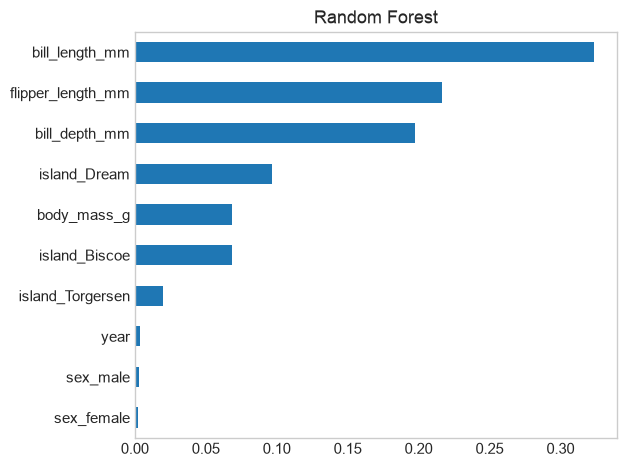

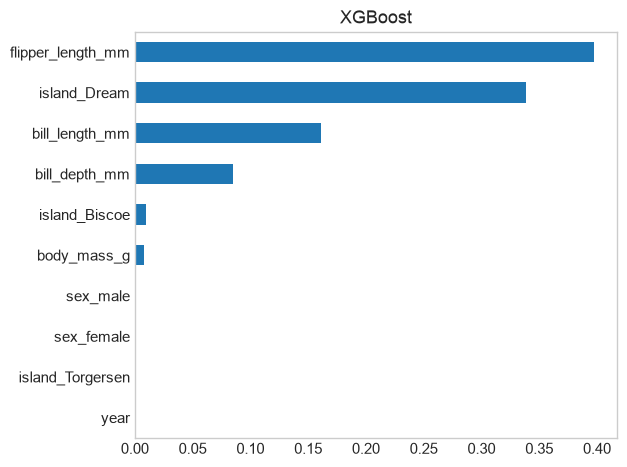

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_importancia(model, nombres, titulo):
    imp = pd.Series(model.feature_importances_, index=nombres).sort_values()
    imp.plot.barh(title=titulo)
    plt.tight_layout(); plt.show()

plot_importancia(mejor_rf_model,  X_train.columns, "Random Forest")
plot_importancia(mejor_xgb_model, X_train.columns, "XGBoost")

## TODO

## Ensamble

In [22]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, f1_score

# --- Bootstrap manual por modelo ---
rng = np.random.default_rng(RANDOM_STATE)

modelos = [mejor_rf_model, mejor_xgb_model, mejor_nn_model]
nn_cfg  = eval(mejor_nn["hiperparametros"])
preds_test  = []
preds_train = []

for m in modelos:
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)

    if isinstance(m, _TFClassifier):
        m.fit(X_train.iloc[idx], y_train[idx],
              epochs=nn_cfg["epochs"], batch_size=nn_cfg["batch_size"], verbose=0)
    else:
        m.fit(X_train.iloc[idx], y_train[idx])

    preds_train.append(m.predict(X_train))
    preds_test.append(m.predict(X_test))

y_ensamble_train = mode(np.vstack(preds_train), axis=0).mode.ravel()
y_ensamble_test  = mode(np.vstack(preds_test),  axis=0).mode.ravel()

print("=== Ensamble Manual (Bootstrap + Voto Mayoritario) ===")
print(f"Train — Accuracy: {accuracy_score(y_train, y_ensamble_train):.4f}  | F1 macro: {f1_score(y_train, y_ensamble_train, average='macro'):.4f}")
print(f"Test  — Accuracy: {accuracy_score(y_test,  y_ensamble_test):.4f}  | F1 macro: {f1_score(y_test,  y_ensamble_test,  average='macro'):.4f}")


=== Ensamble Manual (Bootstrap + Voto Mayoritario) ===
Train — Accuracy: 1.0000  | F1 macro: 1.0000
Test  — Accuracy: 1.0000  | F1 macro: 1.0000


## Comparación de Modelos

In [ ]:
from sklearn.metrics import f1_score

def diagnostico(f1_train, f1_test, umbral_gap=0.05, umbral_bajo=0.80):
    if f1_train < umbral_bajo and f1_test < umbral_bajo:
        return "underfit"
    elif f1_train - f1_test > umbral_gap:
        return "overfit"
    return "bien"

# Ensamble: calculado en tiempo de ejecución (no está en el CSV)
f1_ens_train = f1_score(y_train, y_ensamble_train, average="macro")
f1_ens_test  = f1_score(y_test,  y_ensamble_test,  average="macro")

filas = [
    ("Mejor Random Forest",        mejor_rf["f1_train"],  mejor_rf["f1_test"]),
    ("Mejor XGBoost",              mejor_xgb["f1_train"], mejor_xgb["f1_test"]),
    ("Mejor Red Neuronal",         mejor_nn["f1_train"],  mejor_nn["f1_test"]),
    ("Ensamble (majority voting)", f1_ens_train,          f1_ens_test),
]

tabla = pd.DataFrame(
    [(n, f"{tr:.4f}", f"{te:.4f}", diagnostico(tr, te)) for n, tr, te in filas],
    columns=["MODELO", "F1 (TRAIN)", "F1 (TEST)", "DIAGNÓSTICO"]
).set_index("MODELO")

def colorear(val):
    if val == "overfit":  return "color: #e74c3c; font-weight: bold"
    if val == "underfit": return "color: #e67e22; font-weight: bold"
    if val == "bien":     return "color: #2ecc71; font-weight: bold"
    return ""

tabla.style.map(colorear, subset=["DIAGNÓSTICO"])


AttributeError: 'Styler' object has no attribute 'applymap'